# Credit Risk Modelling Machine Learning Project
## Credit Utilization Feature Engineering & Modeling Tasks

- Generate a new feature called **`credit_utilization_per_income`**. This is simply a ratio of `credit_utilization_ratio` and `loan_to_income`.

- Plot **KDE plot** and record your insights in the notebook.

- Use this feature in the remaining of the notebook all the way till modelling.

- Install `bayesian-optimization` module by running:  
  `pip install bayesian-optimization`

- **Attempt 1:** Use internet/ChatGPT to do some research and write code to use `BayesianOptimization` to find best parameters for logistic regression.

- **Attempt 2:** Use `GridSearchCV` and `XGBoost` to train your model and find best parameters.

- Install `shap` by running:  
  `pip install shap`

- `shap` is a Python library used for AI explainability. Use `TreeExplainer` from this library to explain the best performing XGBoost model that you got in **Attempt 2**.

- Plot `dependence_plot` for `credit_utilization_ratio`.

- Use `shap.force_plot` to draw a plot for a single prediction from `X_test_encoded` array.

In [1]:
#Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries are imported successfully")
pd.set_option('display.float_format',lambda x: '{:.2f}'.format(x))
np.set_printoptions(suppress=True)

All libraries are imported successfully


In [2]:
#Load the data onto the pandas dataframe
customers = pd.read_csv('../data/customers.csv')
loans = pd.read_csv('../data/loans.csv')
bureau = pd.read_csv('../data/bureau_data.csv')

In [3]:
customers.shape

(50000, 12)

In [4]:
loans.shape

(50000, 15)

In [5]:
bureau.shape

(50000, 8)

In [6]:
customers.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001


In [7]:
loans.head(3)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False


In [8]:
bureau.head(3)

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58


In [9]:
#Merge the dataset so that the modelling can be done on a single dataset
df = pd.merge(customers, loans, on='cust_id')
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False


In [10]:
#Merge with bureau data 
df = pd.merge(df,bureau,on='cust_id')
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  str    
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  str    
 3   marital_status               50000 non-null  str    
 4   employment_status            50000 non-null  str    
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  str    
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  str    
 10  state                        50000 non-null  str    
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  str    
 13  loan_purpose               

In [12]:
#Create loan_to_income
df['loan_to_income'] = df['loan_amount']/df['income']

In [13]:
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_to_income
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-08-10,False,1,1,42,0,0,3,7,0.95
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-08-15,False,3,1,96,12,60,5,4,3.22
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-08-21,False,2,1,82,24,147,6,58,0.75


In [14]:
df['credit_utilization_per_income'] = (df['credit_utilization_ratio'] / df['loan_to_income'])

In [15]:
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_to_income,credit_utilization_per_income
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,False,1,1,42,0,0,3,7,0.95,7.34
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,False,3,1,96,12,60,5,4,3.22,1.24
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,False,2,1,82,24,147,6,58,0.75,76.92


In [16]:
#Handle edge cases
import numpy as np
df['credit_utilization_per_income'].replace([np.inf,-np.inf],np.nan,inplace=True)
df['credit_utilization_per_income'].fillna(df['credit_utilization_per_income'].median(),inplace=True)

C:\Users\manan\AppData\Local\Temp\ipykernel_9860\1178638153.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['credit_utilization_per_income'].replace([np.inf,-np.inf],np.nan,inplace=True)
C:\Users\manan\AppData\Local\Temp\ipykernel_9860\1178638153.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Se

0        7.34
1        1.24
2       76.92
3       52.79
4        7.59
         ... 
49995   34.77
49996   87.46
49997   13.50
49998    5.56
49999   14.05
Name: credit_utilization_per_income, Length: 50000, dtype: float64

In [17]:
#Investigate Residence Type Column for missing data
df['residence_type'].isnull().sum()

np.int64(62)

In [18]:
df['residence_type'].value_counts()

residence_type
Owned       28238
Mortgage    11819
Rented       9881
Name: count, dtype: int64

In [19]:
df[df['residence_type'].isnull()].head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_to_income,credit_utilization_per_income
86,C00087,49,M,Single,Self-Employed,4770000,0,NaN,22,Bangalore,...,False,3,2,107,7,34,3,75,2.42,31.01
1072,C01073,40,M,Married,Self-Employed,2068000,3,NaN,30,Bangalore,...,False,2,2,91,14,46,4,27,0.95,28.31
1084,C01085,43,M,Married,Self-Employed,6833000,4,NaN,30,Lucknow,...,False,1,0,10,0,0,5,95,1.51,62.80
3777,C03778,27,M,Single,Salaried,1398000,0,NaN,31,Jaipur,...,False,3,2,91,6,34,7,0,0.86,0.00
5915,C05916,31,M,Single,Salaried,2641000,0,NaN,16,Jaipur,...,False,1,0,53,21,137,4,54,0.83,64.85


In [20]:
df[df['residence_type'].isnull()].describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,...,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_to_income,credit_utilization_per_income
count,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,...,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00
mean,39.03,2849483.87,2.06,14.44,387791.32,4995451.61,4256161.29,85123.23,766109.03,3404929.03,...,1033143.18,2.53,0.97,79.56,5.10,27.34,4.71,41.35,1.51,38.68
std,8.31,2666898.47,1.56,9.44,157168.92,6347416.19,5488589.57,109771.79,987946.12,4390871.66,...,958474.39,1.05,0.87,39.68,5.99,32.75,1.92,29.22,0.92,39.26
min,23.00,197000.00,0.00,1.00,110001.00,292000.00,264000.00,5280.00,47520.00,211200.00,...,83994.00,1.00,0.00,10.00,0.00,0.00,1.00,0.00,0.39,0.00
25%,33.25,885500.00,1.00,6.25,302001.00,1231000.00,1004500.00,20090.00,180810.00,803600.00,...,357253.75,2.00,0.00,50.75,0.00,0.00,3.00,16.25,0.78,10.72
50%,38.50,2071000.00,2.00,13.00,400001.00,3052000.00,2509000.00,50180.00,451620.00,2007200.00,...,642194.50,2.00,1.00,70.00,2.00,14.00,5.00,32.50,1.17,28.14
75%,43.00,3534250.00,3.00,21.75,500001.00,6372250.00,5366000.00,107320.00,965880.00,4292800.00,...,1279148.00,3.00,2.00,104.50,10.00,50.00,6.00,68.00,2.48,54.03
max,61.00,11160000.00,5.00,31.00,700001.00,35048000.00,31153000.00,623060.00,5607540.00,24922400.00,...,3655001.00,4.00,2.00,193.00,23.00,137.00,9.00,99.00,3.34,207.72


In [21]:
df.residence_type.unique()

<ArrowStringArray>
['Owned', 'Mortgage', 'Rented', nan]
Length: 4, dtype: str

In [22]:
df['residence_type'] = df['residence_type'].fillna(df['residence_type'].mode()[0])

In [23]:
df.residence_type.unique()

<ArrowStringArray>
['Owned', 'Mortgage', 'Rented']
Length: 3, dtype: str

In [24]:
df['residence_type'].isnull().sum()

np.int64(0)

In [25]:
df[['loan_to_income', 'credit_utilization_per_income']].describe()

,loan_to_income,credit_utilization_per_income
count,49992.00,49992.00
mean,1.56,40.15
std,0.97,38.41
min,0.30,0.00
25%,0.77,11.79
50%,1.16,27.50
75%,2.45,58.12
max,4.59,294.44


The feature `credit_utilization_per_income` represents the ratio of credit usage relative to a customer's repayment capacity.
Higher values indicate that a customer is utilizing more credit compared to their income level, which may signal higher financial stress and increased probability of default.

In [26]:
df[df['income'] == 0]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_to_income,credit_utilization_per_income
2278,C02279,46,M,Married,Self-Employed,0,2,Rented,26,Pune,...,False,4,2,129,0,0,7,15,NaN,NaN
4950,C04951,42,M,Married,Salaried,0,3,Mortgage,13,Bangalore,...,False,3,0,142,0,0,7,37,NaN,NaN
11092,C11093,39,F,Single,Salaried,0,0,Rented,17,Chennai,...,False,2,1,67,0,0,5,12,NaN,NaN
13356,C13357,34,F,Single,Self-Employed,0,1,Owned,2,Delhi,...,False,2,2,63,22,125,3,28,NaN,NaN
27457,C27458,48,F,Married,Self-Employed,0,3,Owned,5,Pune,...,False,4,1,72,0,0,7,89,NaN,NaN
45224,C45225,43,M,Married,Salaried,0,4,Mortgage,30,Chennai,...,False,3,1,112,10,53,7,30,NaN,NaN
46640,C46641,28,F,Married,Salaried,0,4,Rented,24,Jaipur,...,False,2,0,73,0,0,6,30,NaN,NaN
47428,C47429,27,M,Single,Self-Employed,0,0,Owned,19,Lucknow,...,False,4,0,99,15,87,4,37,NaN,NaN


In [27]:
df['income'] = df['income'].replace(0, np.nan)
df['income'] = df['income'].fillna(df['income'].median())

In [28]:
df['loan_to_income'] = df['loan_amount'] / df['income']

In [29]:
df[df['income'] == 0]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_to_income,credit_utilization_per_income


In [30]:
df[['loan_to_income', 'credit_utilization_per_income']].describe()

,loan_to_income,credit_utilization_per_income
count,50000.00,49992.00
mean,1.55,40.15
std,0.97,38.41
min,0.00,0.00
25%,0.77,11.79
50%,1.16,27.50
75%,2.45,58.12
max,4.59,294.44


In [31]:
df['loan_to_income'] = df['loan_amount'] / df['income']

df['credit_utilization_per_income'] = (
    df['credit_utilization_ratio'] / df['loan_to_income']
)

df['credit_utilization_per_income'] = df['credit_utilization_per_income'].replace(
    [np.inf, -np.inf], np.nan
)

df['credit_utilization_per_income'] = df['credit_utilization_per_income'].fillna(
    df['credit_utilization_per_income'].median()
)

In [32]:
df[['loan_to_income', 'credit_utilization_per_income']].describe()

,loan_to_income,credit_utilization_per_income
count,50000.00,50000.00
mean,1.55,40.15
std,0.97,38.41
min,0.00,0.00
25%,0.77,11.80
50%,1.16,27.50
75%,2.45,58.11
max,4.59,294.44


In [33]:
df[['loan_to_income', 'credit_utilization_per_income']].isnull().sum()

loan_to_income                   0
credit_utilization_per_income    0
dtype: int64

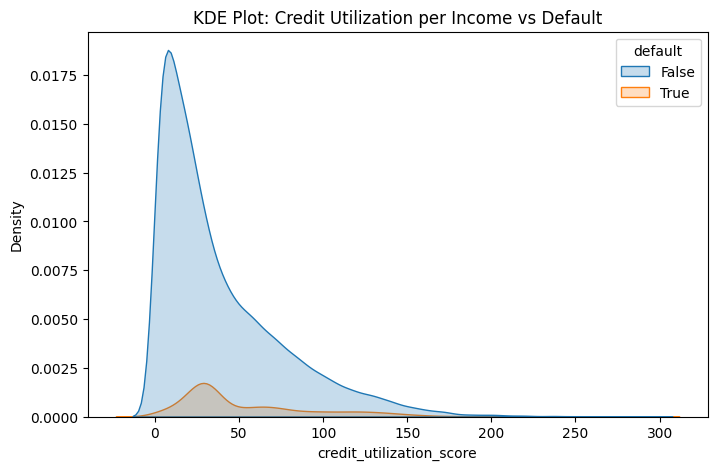

In [34]:
#KDE Plot
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x='credit_utilization_per_income',
    hue='default',
    fill=True)
plt.title("KDE Plot: Credit Utilization per Income vs Default")
plt.xlabel("credit_utilization_score")
plt.ylabel("Density")
plt.show()

### Insights from KDE Plot
- **"Customers who default tend to have higher values of `credit_utilization_per_income`, indicating higher financial basis.**
- The distribution appears **right-skewed**, suggesting that a subset of customers has significantly **high credit utilization relative to income**
- There is a clear and visible separation between default and non default classes, making this feature potentially useful for predictive learning.
- This engineered feature captures risk more effectively than individual variables alone. 

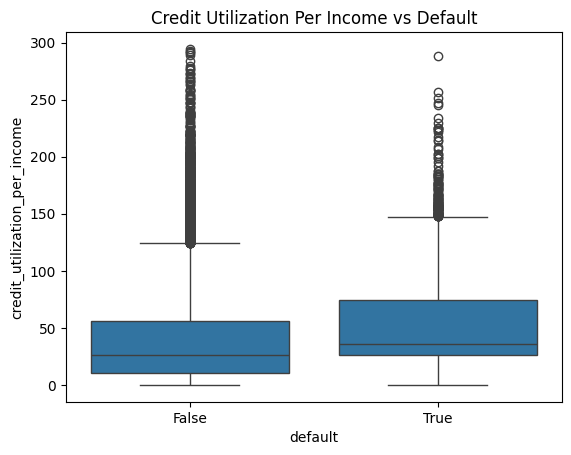

In [35]:
#Box Plot
sns.boxplot(x='default',y='credit_utilization_per_income',data=df)
plt.title('Credit Utilization Per Income vs Default')
plt.show()

# Data Preprocessing 

In [36]:
#Separate the features and target columns
y = df['default']
X = df.drop(columns=['default'])

In [37]:
y.head()

0    False
1    False
2    False
3    False
4    False
Name: default, dtype: bool

In [38]:
X = X.drop(columns=[
    'cust_id',
    'loan_id',
    'zipcode',
    'disbursal_date',
    'installment_start_dt',
    'city',
    'state',
    'delinquent_months',
    'total_dpd',
    'principal_outstanding'])

In [39]:
df['loan_purpose'] = df['loan_purpose'].replace('Personaal', 'Personal')

In [40]:
categorical_cols = X.select_dtypes(include='object').columns
print(categorical_cols)

Index(['gender', 'marital_status', 'employment_status', 'residence_type',
       'loan_purpose', 'loan_type'],
      dtype='str')


C:\Users\manan\AppData\Local\Temp\ipykernel_9860\2157240112.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns


In [41]:
numeric_cols = X.select_dtypes(exclude='object').columns
print(numeric_cols)

Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'enquiry_count', 'credit_utilization_ratio',
       'loan_to_income', 'credit_utilization_per_income'],
      dtype='str')


In [42]:
#Handle Missing Values General Approach for numerical columns
#Numerical
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

In [43]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            50000 non-null  int64  
 1   gender                         50000 non-null  str    
 2   marital_status                 50000 non-null  str    
 3   employment_status              50000 non-null  str    
 4   income                         50000 non-null  float64
 5   number_of_dependants           50000 non-null  int64  
 6   residence_type                 50000 non-null  str    
 7   years_at_current_address       50000 non-null  int64  
 8   loan_purpose                   50000 non-null  str    
 9   loan_type                      50000 non-null  str    
 10  sanction_amount                50000 non-null  int64  
 11  loan_amount                    50000 non-null  int64  
 12  processing_fee                 50000 non-null  float64
 1

In [44]:
#Handle missing values for categorical columns using general methods such as mode

In [45]:
X[categorical_cols] = X[categorical_cols].fillna(X[categorical_cols].mode().iloc[0])

In [46]:
#Encode the categorical column values using one hot encoding (safe choice)
X_encoded = pd.get_dummies(X,columns=categorical_cols,drop_first=True)

In [47]:
X_encoded.head()

,age,income,number_of_dependants,years_at_current_address,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,...,gender_M,marital_status_Single,employment_status_Self-Employed,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personaal,loan_purpose_Personal,loan_type_Unsecured
0,44,2586000.00,3,27,3004000,2467000,49340.00,444060,1973600,33,...,True,False,True,True,False,False,False,False,False,False
1,38,1206000.00,3,4,4161000,3883000,77660.00,698940,3106400,30,...,True,False,False,True,False,False,True,False,False,False
2,46,2878000.00,3,24,2401000,2170000,43400.00,390600,1736000,21,...,False,False,True,True,False,False,False,False,True,True
3,55,3547000.00,1,15,2345000,1747000,34940.00,314460,1397600,6,...,False,True,True,True,False,False,False,False,True,True
4,37,3432000.00,3,28,4647000,4520000,90400.00,813600,3616000,28,...,True,False,False,True,False,False,False,False,False,False


In [48]:
#Train Test Split the prepared data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded,y,test_size=0.2,random_state=42,stratify=y)

In [49]:
#Feature Scaling for Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.fit_transform(X_test[numeric_cols])

# Summary Of Feature Engineering
- Categorical values were encoded using One - Hot Encoding to convert them into numerical form suitable for machine learning models.
- Numerical features were scaled using StandardScaler to ensure the uniform contribution across features, especially logistic regression.

In [50]:
#Sanity check after feature engineering, exploratory data analysis and checking the shape
X_train_scaled.shape

(40000, 28)

In [51]:
X_test_scaled.shape

(10000, 28)

# Bayesian Probabilistic Approach - Attempt 1
Instead of learning a single set of model parameters, (like standard neural nets), Bayesian models treat parameters as **probability distributions**.
They combine **prior beliefs** (prior distribution) with observed data (likelihood) to compute an update belief. (posterior distribution), using Bayes' Theorem

In [52]:
pip install bayesian-optimization

Note: you may need to restart the kernel to use updated packages.


In [53]:
#Define Optimization Function
from bayes_opt import BayesianOptimization
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
def lr_eval(C,max_iter):
    model = LogisticRegression(
        C=C,
        max_iter = int(max_iter),
        solver = 'liblinear'
    )
    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=3,
        scoring='roc_auc'
    ).mean()
    return score

In [54]:
#Define Search Space
pbounds = {
    'C':(0.01,10),
    'max_iter':(100,500)
}

In [55]:
optimizer = BayesianOptimization(
    f=lr_eval,
    pbounds=pbounds,
    random_state=42
)

optimizer.maximize(
    init_points=5,
    n_iter=10
)

|   iter    |  target   |     C     | max_iter  |
-------------------------------------------------
| 1         | 0.9398100 | 3.7516557 | 480.28572 |
| 2         | 0.9398050 | 7.3226194 | 339.46339 |
| 3         | 0.9398143 | 1.5686262 | 162.39780 |
| 4         | 0.9398216 | 0.5902552 | 446.47045 |
| 5         | 0.9398060 | 6.0151389 | 383.22903 |
| 6         | 0.9398175 | 1.2226355 | 445.86364 |
| 7         | 0.9397790 | 0.2029444 | 448.04688 |
| 8         | 0.9398205 | 0.4673748 | 445.61961 |
| 9         | 0.9398227 | 0.7811057 | 444.31159 |
| 10        | 0.9396763 | 0.1213616 | 443.55986 |
| 11        | 0.9398127 | 1.7166911 | 162.57074 |
| 12        | 0.9398065 | 5.8689372 | 492.34535 |
| 13        | 0.9398141 | 1.5914902 | 444.27299 |
| 14        | 0.9398091 | 4.0081563 | 181.37937 |
| 15        | 0.9398141 | 0.3379729 | 444.88977 |


In [56]:
print(optimizer.max)

{'target': np.float64(0.939822750834182), 'params': {'C': np.float64(0.7811057556284555), 'max_iter': np.float64(444.31159369575323)}}


In [57]:
#Train Final Model
best_params = optimizer.max['params']
lr_model = LogisticRegression(
    C=best_params['C'],
    max_iter = int(best_params['max_iter']),
    solver='liblinear'
)
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0.7811057556284555)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class o

In [58]:
#Evaluate the model
from sklearn.metrics import roc_auc_score
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test,y_pred_proba)
print(f"ROC AUC Score: {roc_auc}")

ROC AUC Score: 0.9447822937986549


In [59]:
X_encoded.columns

Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'enquiry_count', 'credit_utilization_ratio',
       'loan_to_income', 'credit_utilization_per_income', 'gender_M',
       'marital_status_Single', 'employment_status_Self-Employed',
       'residence_type_Owned', 'residence_type_Rented',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personaal',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='str')